In [19]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [20]:
prep_circuit = QuantumCircuit(1,name='prep')
prep_circuit.u(0.7, 18.8, 2.1, 0)

reg_in = QuantumRegister(1, name='in')
reg_out = QuantumRegister(2, name='out')
res_in = ClassicalRegister(1)
res_ent = ClassicalRegister(1)


In [21]:
circuit = QuantumCircuit(reg_in, reg_out, res_in, res_ent)

circuit.compose(prep_circuit, qubits=reg_in, inplace=True)
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "in"), index=0>, <Qubit register=(2, "out"), index=0>, <Qubit register=(2, "out"), index=1>), clbits=())

In [22]:
circuit.h(reg_out[0])
circuit.cx(reg_out[0], reg_out[1])

circuit.cx(reg_in[0], reg_out[0])

circuit.h(reg_in[0])

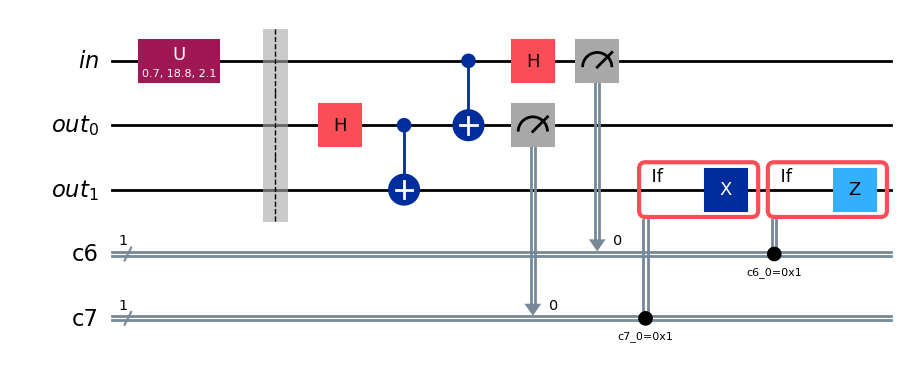

In [23]:
circuit.measure(reg_in[0],res_in[0])

circuit.measure(reg_out[0], res_ent[0])

with circuit.if_test((res_ent[0], 1)):
    circuit.x(reg_out[1])
with circuit.if_test((res_in[0], 1)):
    circuit.z(reg_out[1])
    
circuit.draw("mpl")

In [24]:
Math(statevector_expr(prep_circuit, state_label=r'\text{in}'))

<IPython.core.display.Math object>